# Detecção de Componentes Eletrônicos em PCB com YOLOv8

**Projeto 3 — Deep Learning**

**Integrantes:** Julio Cesar de Sousa Fernandes (2316701), Roberto Nascimento Xavier (2316446), Cauã Bilhar Dacca (2315904), Thiago Neves de Carvalho (2316921)

**Repositório GitHub:** _[colar o link do repositório aqui]_

---

Este notebook treina e avalia um modelo de detecção de objetos (YOLOv8) para identificar
**componentes eletrônicos em placas de circuito impresso (PCB)**. As 6 classes detectadas
— BGA, Capacitor, Diode, IC, Mosfet e Transistor — **não pertencem às 80 categorias do
dataset COCO**, atendendo ao requisito de classe inédita do projeto.

**Modelo principal:** YOLOv8m, resolução 640.
**Experimento comparativo:** o mesmo modelo treinado em resolução 960 (ver seção final).

Etapas:
1. Download do dataset rotulado no formato YOLO (Roboflow)
2. Treinamento do modelo YOLOv8m (640)
3. Avaliação por métricas (mAP, Precisão, Recall) e análise dos gráficos
4. Aplicação prática em uma imagem real capturada pelo grupo
5. Experimento comparativo de resolução (640 vs 960)


# Pacotes

Instala os pacotes ultralytics (YOLO) e roboflow

In [1]:
!pip install ultralytics --quiet
!pip install roboflow --quiet
import ultralytics
ultralytics.checks()


Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [ ]:
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from roboflow import Roboflow

rf = Roboflow(api_key="API_KEY")
project = rf.workspace("rafael-fjjhj").project("pcb-components-8hkfx-3xa9m")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PCB-Components-1 in yolov8:: 100%|██████████| 1005/1005 [00:00<00:00, 2503.52it/s]


In [3]:
print(dataset.location)
!cat {dataset.location}/data.yaml


/content/PCB-Components-1
names:
- BGA
- Capacitor
- Diode
- IC
- Mosfet
- Transistor
nc: 6
roboflow:
  license: CC BY 4.0
  project: pcb-components-8hkfx-3xa9m
  url: https://universe.roboflow.com/rafael-fjjhj/pcb-components-8hkfx-3xa9m/dataset/1
  version: 1
  workspace: rafael-fjjhj
test: ../test/images
train: ../train/images
val: ../valid/images


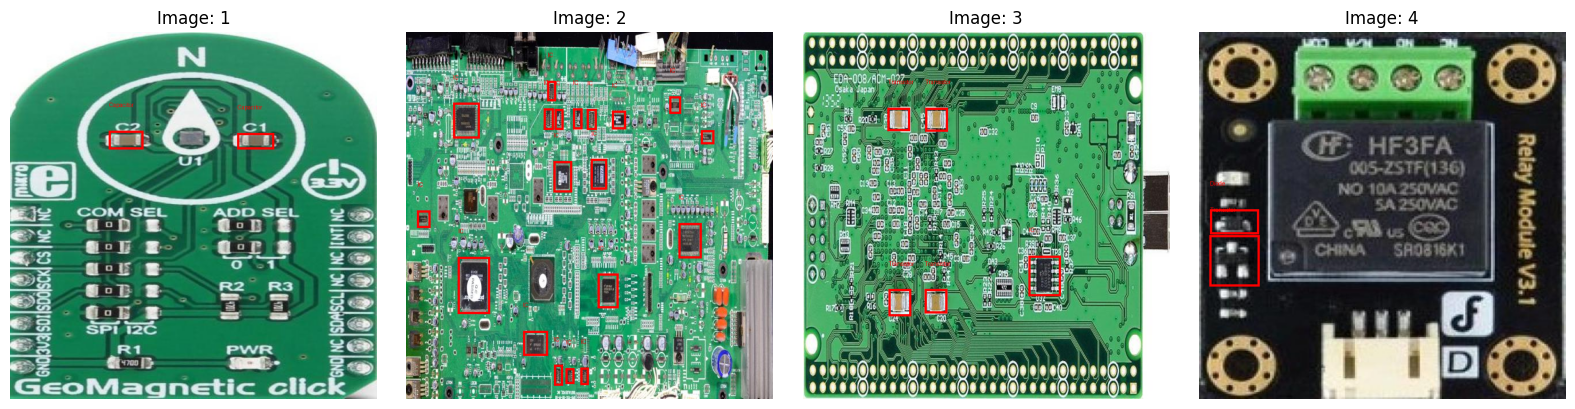

In [4]:
test_img_dir = f"{dataset.location}/test/images"
test_label_dir = f"{dataset.location}/test/labels"

nomes_classes = ['BGA','Capacitor','Diode','IC','Mosfet','Transistor']

# Selecionar 4 imagens aleatórias
image_files = [f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
sample_images = random.sample(image_files, 4)

plt.figure(figsize=(16, 4))

for i, img_file in enumerate(sample_images):
    # Caminhos da imagem e do label
    img_path = os.path.join(test_img_dir, img_file)
    label_path = os.path.join(test_label_dir, os.path.splitext(img_file)[0] + '.txt')

    # Abrir imagem
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w, h = img.size
    font_size = max(int(w * 0.08), 12)

    # Tenta carregar uma fonte padrão, se disponível
    try:
        font = ImageFont.truetype("arial.ttf", font_size) # Usando arial.ttf como exemplo
    except IOError:
        font = ImageFont.load_default() # Fallback para a fonte padrão do PIL

    # Desenhar bounding boxes e classes
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, box_w, box_h = map(float, parts[1:5])
                x1 = (x_center - box_w / 2) * w
                y1 = (y_center - box_h / 2) * h
                x2 = (x_center + box_w / 2) * w
                y2 = (y_center + box_h / 2) * h

                # Caixa
                draw.rectangle([x1, y1, x2, y2], outline='red', width=4)

                # Texto da classe (acima da caixa)
                classe = nomes_classes[class_id] if class_id < len(nomes_classes) else f"Classe {class_id}"
                draw.text((x1, y1-font_size), classe, fill='red', font=font)

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Image: ' + str(i+1))

plt.tight_layout()
plt.show()

## Estrutura esperada dos dados (YOLO)

O diretório do dataset deve ser estruturado da seguinte forma:

```
dataset/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── test/
│   ├── images/
│   └── labels/
└── data.yaml
```

## Estrutura do arquivo `data.yaml`

O arquivo `data.yaml` informa onde estao os dados, quantas classes existem e os nomes delas.
Neste projeto, o arquivo baixado do Roboflow tem a seguinte estrutura:

```yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['BGA', 'Capacitor', 'Diode', 'IC', 'Mosfet', 'Transistor']
```


In [5]:
# Codigo opcional para reescrever o data.yaml com caminhos absolutos,
# caso o treino acuse "imagens nao encontradas". Normalmente NAO e necessario.

# import yaml
# yaml_path = f"{dataset.location}/data.yaml"
# with open(yaml_path) as f:
#     data = yaml.safe_load(f)
# data["train"] = f"{dataset.location}/train/images"
# data["val"]   = f"{dataset.location}/valid/images"
# data["test"]  = f"{dataset.location}/test/images"
# with open(yaml_path, "w") as f:
#     yaml.dump(data, f, sort_keys=False)


# Treinamento do modelo YOLO

O **modelo principal** deste projeto é o **YOLOv8m** (25,9 milhões de parâmetros), treinado na
resolução padrão de **640**. O YOLOv8 oferece variações de tamanho (n, s, m, l, x); escolhemos
o *medium* por equilibrar capacidade de representação e custo computacional, cabendo na VRAM
de 16 GB disponível no ambiente de treino (Google Colab / GPU Tesla T4).


Os parâmetros de configuração dos modelos YOLO podem ser consultados na documentação oficial em: https://docs.ultralytics.com/pt/modes/train/, onde estão descritas as opções de treino, validação, tamanhos de imagem, número de épocas, otimizadores, etc.

In [6]:
# liberar a memória da GPU
import gc
import torch

gc.collect()  # limpa objetos Python não utilizados
torch.cuda.empty_cache()  # limpa cache CUDA

In [7]:
from ultralytics import YOLO

# Modelo PRINCIPAL do projeto: YOLOv8m na resolucao padrao 640.
model = YOLO('yolov8m.pt')

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=80,        # com early stopping; convergiu por volta da epoca 54
    imgsz=640,        # resolucao padrao do YOLO
    batch=32,         # coube na VRAM de 16GB sem estourar a memoria
    patience=20,      # early stopping: para se nao houver melhora em 20 epocas
    seed=42,          # reprodutibilidade
    name='pcb_yolov8m',
    plots=True        # gera results.png, matriz de confusao e curvas P-R / F1
)


Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PCB-Components-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pcb_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x790b5847d190>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

Imagem com data augmentation gerada durante o treinamento

⚠️ Importante: Esta imagem não faz parte diretamente do dataset original.

Ela é uma visualização com data augmentation aplicada em um batch de treino.

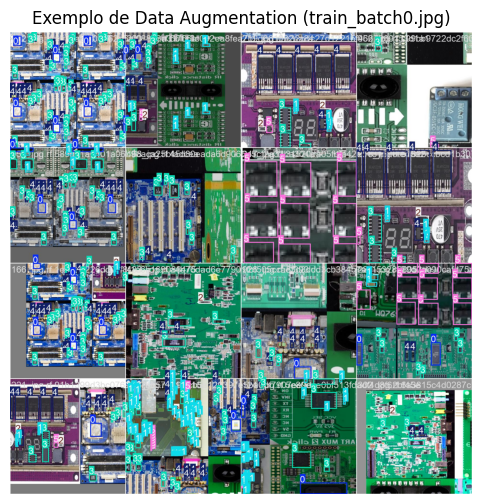

In [8]:
# Exibe a imagem de um batch de treino com data augmentation aplicada.
# Usa dinamicamente a pasta do treino desta sessao.
aug_dir = model.trainer.save_dir
aug_img_path = os.path.join(aug_dir, 'train_batch0.jpg')

if os.path.exists(aug_img_path):
    img = Image.open(aug_img_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Exemplo de Data Augmentation (train_batch0.jpg)")
    plt.show()
else:
    print(f"Imagem de lote nao encontrada em '{aug_img_path}'.")


# Avaliação do Modelo

In [9]:
# Avaliacao final no conjunto de TESTE (dados nunca vistos no treino/validacao)
results = model.val(data=f"{dataset.location}/data.yaml", split='test')


Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10.3±4.3 MB/s, size: 75.3 KB)
val: Scanning /content/PCB-Components-1/test/labels... 76 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 299.0it/s 0.3s
val: New cache created: /content/PCB-Components-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.2s
                   all         76        686      0.614      0.488      0.502      0.299
                   BGA         10         13      0.575      0.846      0.814      0.614
             Capacitor         32        265      0.338        0.2      0.199     0.0787
                 Diode         11         17       0.47      0.353      0.311      0.192
                    IC         56        249      0.789      0.799       0.

In [10]:
# Principais metricas do modelo principal (640)
metrics = results.results_dict
print("Precisao media:", f"{metrics.get('metrics/precision(B)'):.4f}")
print("Revocacao media:", f"{metrics.get('metrics/recall(B)'):.4f}")
print("mAP@0.5:", f"{metrics.get('metrics/mAP50(B)'):.4f}")
print("mAP@0.5:0.95:", f"{metrics.get('metrics/mAP50-95(B)'):.4f}")


Precisao media: 0.6143
Revocacao media: 0.4881
mAP@0.5: 0.5020
mAP@0.5:0.95: 0.2988


results.png


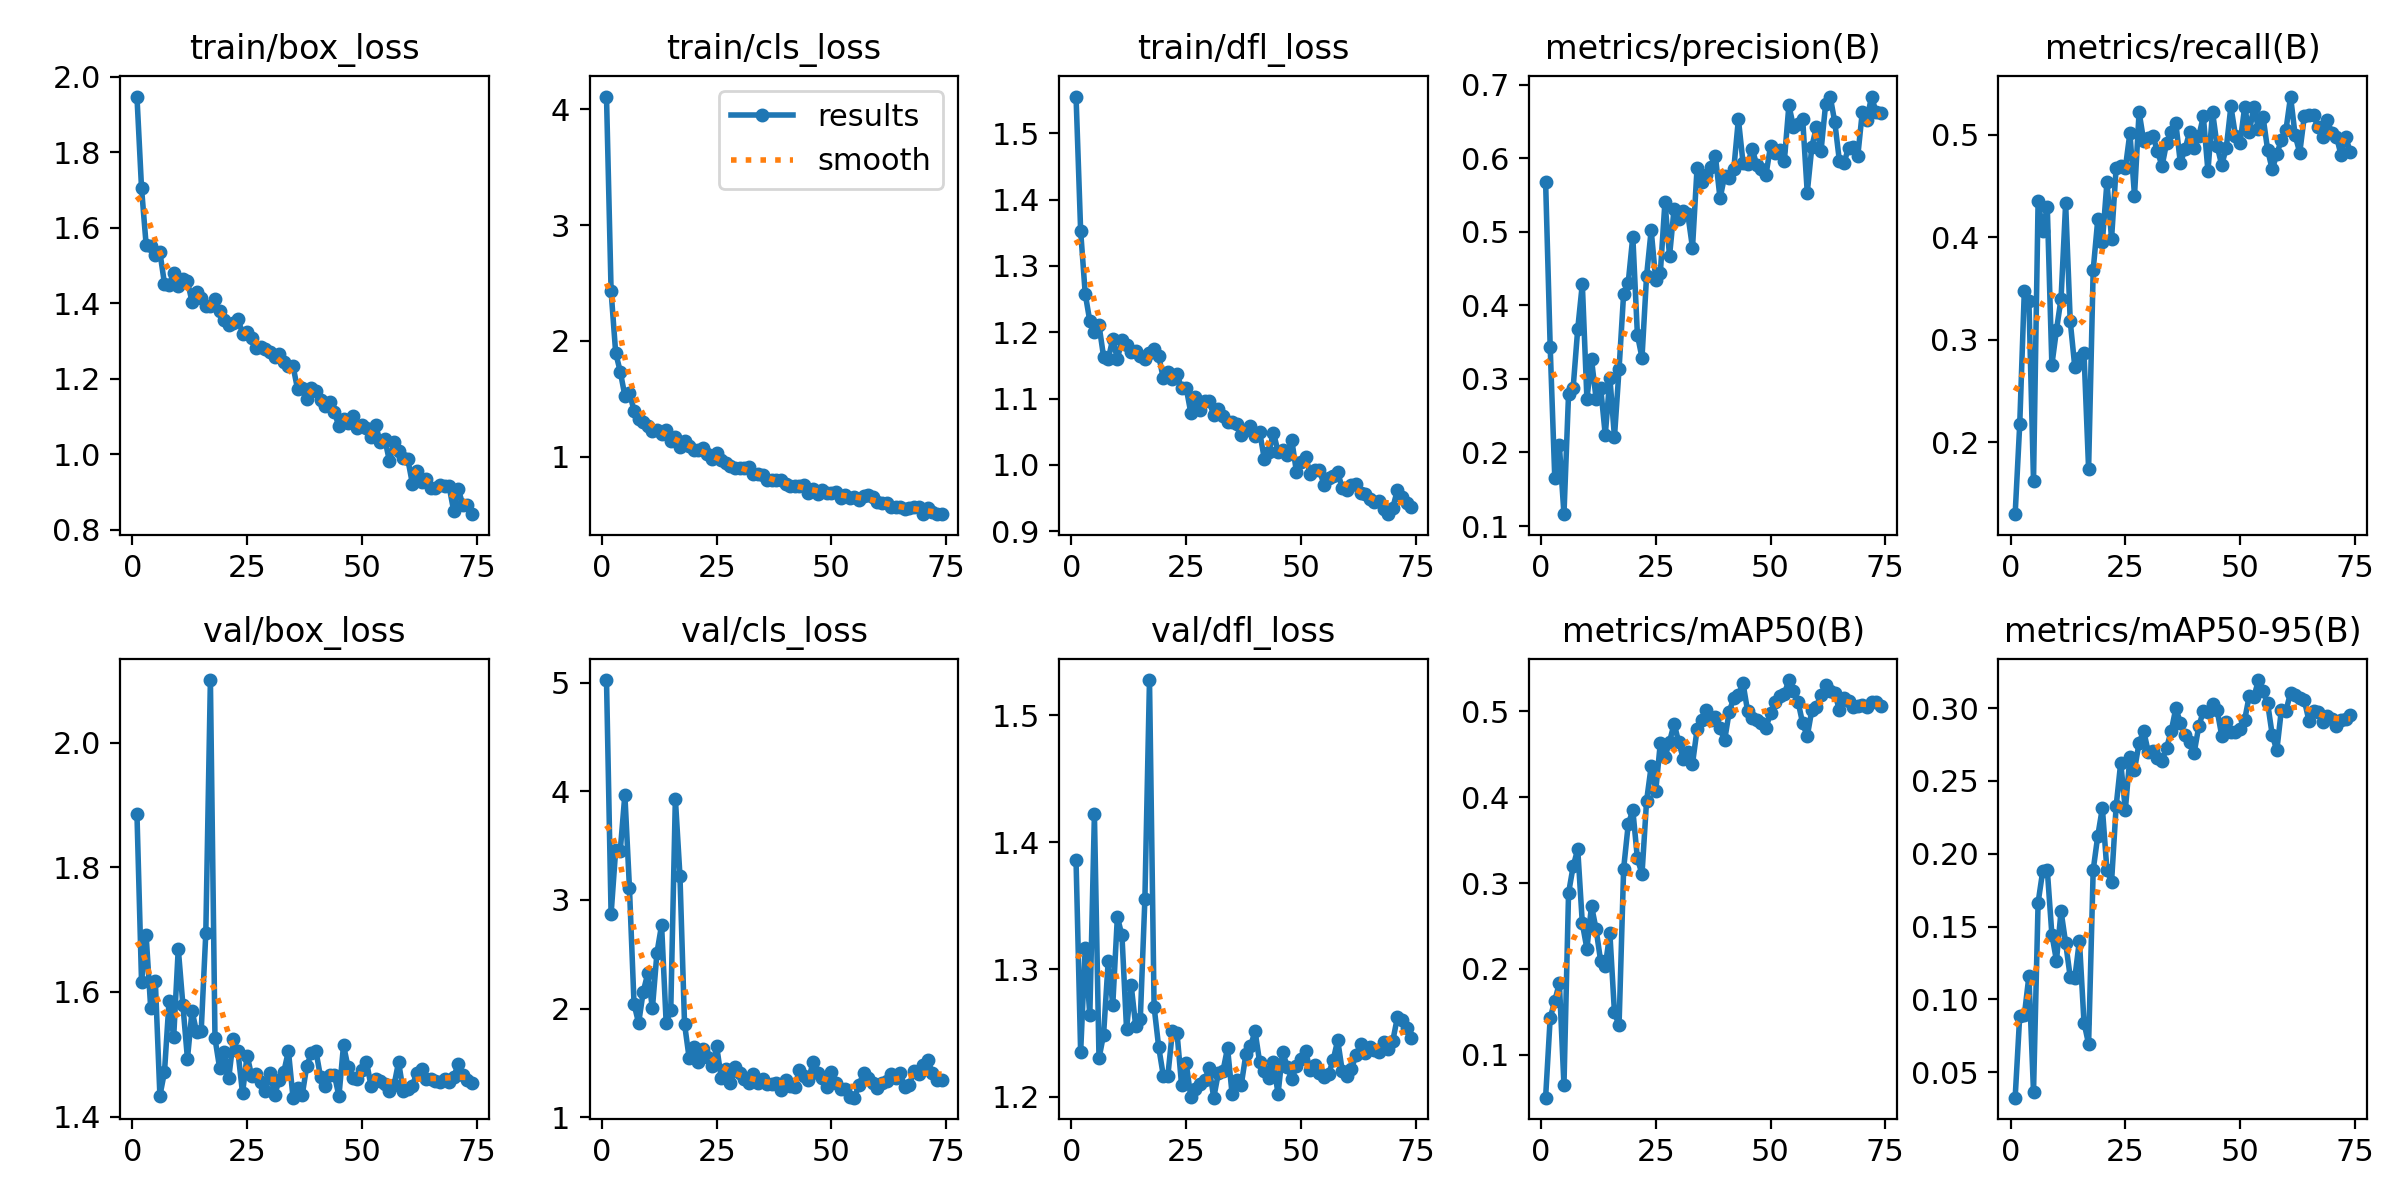

confusion_matrix.png


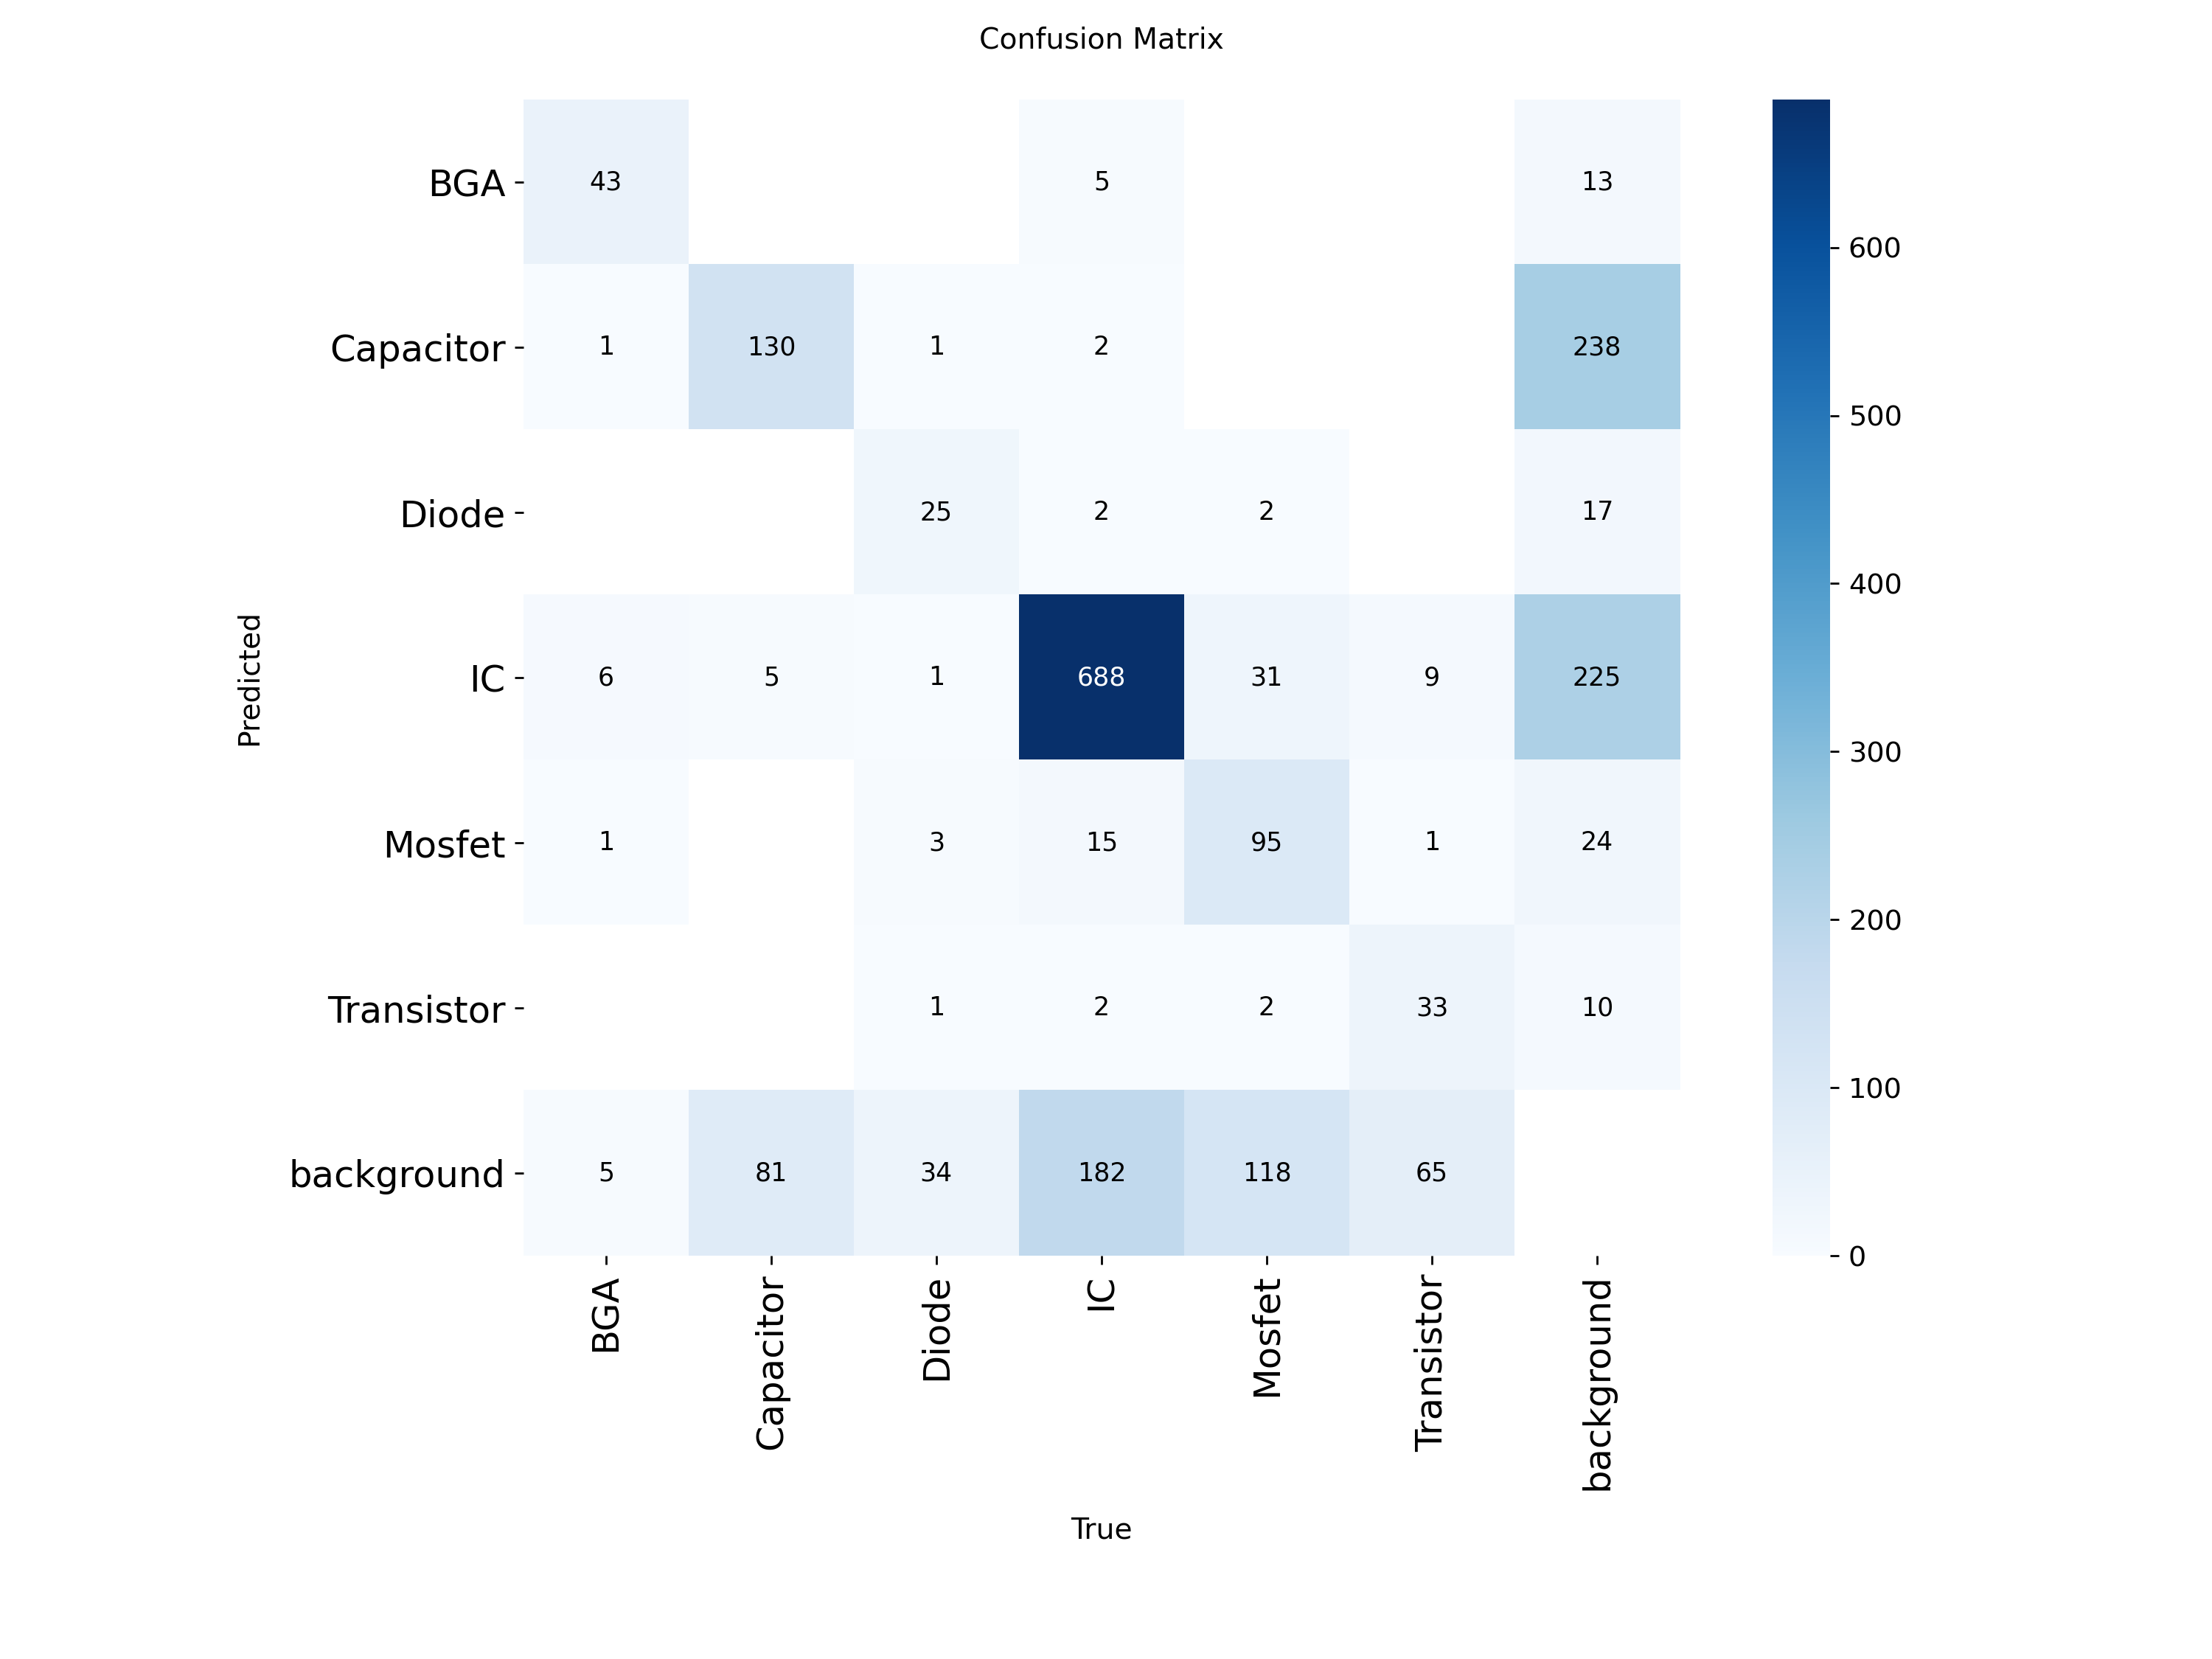

In [11]:
# Graficos gerados automaticamente durante o treino do modelo principal
from IPython.display import Image as IPImage, display

base = model.trainer.save_dir
for g in ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png']:
    caminho = os.path.join(base, g)
    if os.path.exists(caminho):
        print(g)
        display(IPImage(filename=caminho))


## Análise dos Resultados (modelo principal — 640)

Métricas obtidas no **conjunto de teste** (76 imagens, 686 instâncias), dados nunca vistos no treino.

### Métricas globais x baseline publicado do dataset

| Métrica       | Nosso modelo (640) | Baseline |
|---------------|:------------------:|:--------:|
| Precisão      | 0,614              | 0,556    |
| Recall        | 0,488              | 0,476    |
| mAP@0.5       | 0,502              | 0,486    |
| mAP@0.5:0.95  | 0,299              | —        |

O modelo **supera o baseline publicado** do dataset nas três métricas comparáveis, ainda que por
margem modesta. O treino foi interrompido por *early stopping* (época 74/80, melhor desempenho na
época 54), indicando convergência — épocas adicionais não trariam ganho.

### Desempenho por classe (conjunto de teste)

| Classe     | Instâncias | Precisão | Recall | mAP@0.5 |
|------------|:----------:|:--------:|:------:|:-------:|
| IC         | 249        | 0,789    | 0,799  | 0,820   |
| BGA        | 13         | 0,575    | 0,846  | 0,814   |
| Transistor | 97         | 0,882    | 0,464  | 0,563   |
| Mosfet     | 45         | 0,631    | 0,266  | 0,305   |
| Diode      | 17         | 0,470    | 0,353  | 0,311   |
| Capacitor  | 265        | 0,338    | 0,200  | 0,199   |

**Melhores classes — IC e BGA.** IC é a classe com mais exemplos (249 instâncias) e tem o melhor
mAP (0,820). BGA também apresenta mAP alto (0,814), embora com poucas instâncias (13), o que torna
sua métrica menos estável.

**Capacitor é o caso mais difícil.** Apesar de ser a classe mais frequente (265 instâncias), tem o
pior desempenho (mAP 0,199, recall 0,200). A grande variação de aparência e o tamanho reduzido dos
capacitores geram muitos erros de detecção.

**Recall baixo em Mosfet e Diode.** O modelo tem boa precisão mas deixa de detectar muitos objetos
dessas classes (recall 0,27 e 0,35), que são visualmente semelhantes a outros componentes.

### Análise dos gráficos de treino
- **results.png:** as curvas de *loss* (box/cls/dfl) caem de forma consistente e estabilizam, sem
  divergência acentuada entre treino e validação — sinal de convergência sem overfitting severo.
- **Matriz de confusão:** concentra os erros entre as classes de componentes pequenos e
  semelhantes (Capacitor, Mosfet, Diode), confirmando essa similaridade como principal fonte de erro.
- **Curvas P-R e F1:** evidenciam o compromisso entre precisão e recall; o pico da curva F1 indica
  o limiar de confiança de melhor equilíbrio.

### Desafios
Detecção de componentes em PCB é uma tarefa intrinsecamente difícil — componentes pequenos,
numerosos por imagem e visualmente parecidos. Isso explica por que até o baseline da literatura
fica em torno de 48% de mAP.

# Predição na imagem capturada

In [12]:
# Aplicacao pratica: enviar uma imagem REAL de PCB capturada pelo grupo
from google.colab import files

uploaded = files.upload()              # selecione a foto da placa tirada por voces
minha_foto = list(uploaded.keys())[0]
print("Imagem enviada:", minha_foto)


Saving placamae (1).jpg to placamae (1).jpg
Imagem enviada: placamae (1).jpg



image 1/1 /content/placamae (1).jpg: 640x480 1 IC, 49.9ms
Speed: 3.2ms preprocess, 49.9ms inference, 6.2ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/PCB-Components-1/test/images/77_jpg.rf.f74d456e6f4de5a869508ce8f7710023.jpg: 640x640 1 Capacitor, 1 IC, 37.6ms
Speed: 2.2ms preprocess, 37.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


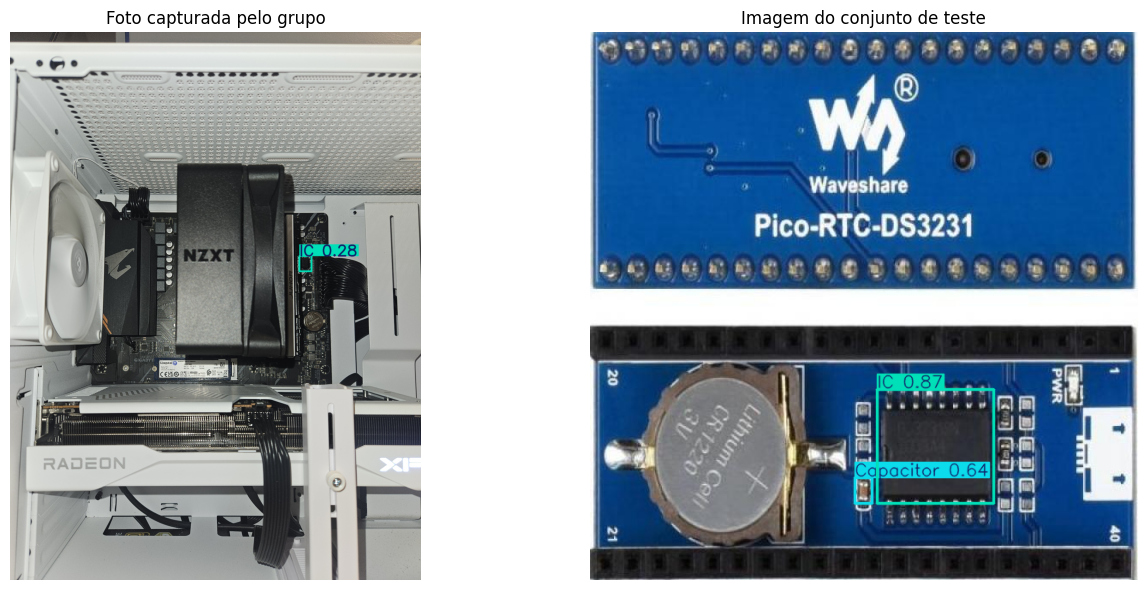

In [13]:
# Inferencia na foto do grupo + uma imagem do conjunto de teste (para comparacao)
test_images = glob.glob(f"{dataset.location}/test/images/*.jpg")
image_paths = [minha_foto, random.choice(test_images)]

preds = [model.predict(p)[0] for p in image_paths]

plt.figure(figsize=(14, 6))
titulos = ["Foto capturada pelo grupo", "Imagem do conjunto de teste"]
for i, pred in enumerate(preds):
    plt.subplot(1, len(image_paths), i + 1)
    plt.imshow(pred.plot()[:, :, ::-1])   # BGR -> RGB
    plt.title(titulos[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [14]:
# Detalhe das deteccoes na foto capturada (classe + confianca de cada caixa)
resultado = preds[0]
nomes = resultado.names
print(f"{len(resultado.boxes)} objetos detectados na foto do grupo:\n")
for box in resultado.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(f" - {nomes[cls_id]:12s}  confianca: {conf:.2f}")


1 objetos detectados na foto do grupo:

 - IC            confianca: 0.28


## Análise crítica da aplicação prática

Ao aplicar o modelo em uma **foto real capturada pelo grupo**, o desempenho foi visivelmente
inferior ao obtido no conjunto de teste: o modelo detectou apenas **1 componente (um IC, com 28% de
confiança)**, deixando de identificar os demais componentes presentes na placa.

Esse resultado é explicado principalmente pelo **domain shift** (mudança de domínio): o dataset de
treino é composto por imagens de PCB capturadas em condições padronizadas (vista superior,
iluminação controlada, distância e resolução específicas). A foto do grupo, tirada em condições
diferentes — ângulo, iluminação, fundo e escala distintos —, representa uma distribuição de dados
que o modelo nunca viu durante o treino. Com apenas 272 imagens de treino, o modelo não teve
exposição suficiente a essa variabilidade para generalizar bem.

Isso ilustra uma limitação importante de modelos treinados em datasets pequenos e homogêneos: o bom
desempenho em dados de teste do mesmo domínio **não garante** desempenho equivalente em dados reais
fora do domínio. Estratégias para mitigar isso incluem: capturar imagens em condições semelhantes às
do treino, aumentar e diversificar o dataset, reforçar o *data augmentation*, ou reduzir o limiar de
confiança na inferência para aumentar o recall.

# Experimento Comparativo: Resolução 640 vs 960

Para avaliar o impacto da resolução de entrada na detecção de componentes pequenos, treinamos
uma segunda versão do **mesmo modelo (YOLOv8m)** usando `imgsz=960` em vez de 640, mantendo o
restante do protocolo. A hipótese era que mais resolução melhoraria a detecção.


In [15]:
# EXPERIMENTO: mesma arquitetura, resolucao 960 (vs 640 do modelo principal).
# Usamos a variavel model_v2 para NAO sobrescrever o modelo principal (model).
model_v2 = YOLO('yolov8m.pt')

model_v2.train(
    data=f"{dataset.location}/data.yaml",
    epochs=150,       # mais teto; o early stopping decide quando parar
    imgsz=960,        # maior resolucao
    batch=16,         # reduzido porque imgsz maior consome mais VRAM
    patience=30,
    seed=42,
    name='pcb_yolov8m_960',
    plots=True
)


Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PCB-Components-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pcb_yolov8m_960, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x790bd06777d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [16]:
# Avaliacao do experimento (960) no mesmo conjunto de teste
results_v2 = model_v2.val(data=f"{dataset.location}/data.yaml", split='test')
m2 = results_v2.results_dict
print("[960] Precisao:", f"{m2.get('metrics/precision(B)'):.4f}")
print("[960] Recall:", f"{m2.get('metrics/recall(B)'):.4f}")
print("[960] mAP@0.5:", f"{m2.get('metrics/mAP50(B)'):.4f}")
print("[960] mAP@0.5:0.95:", f"{m2.get('metrics/mAP50-95(B)'):.4f}")


Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 43.9±18.2 MB/s, size: 80.1 KB)
val: Scanning /content/PCB-Components-1/test/labels.cache... 76 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3s/it 6.6s
                   all         76        686      0.506      0.535      0.484      0.288
                   BGA         10         13      0.606      0.846      0.752      0.601
             Capacitor         32        265      0.233      0.223      0.187     0.0729
                 Diode         11         17      0.216      0.412      0.256      0.135
                    IC         56        249      0.785      0.739      0.808      0.483
                Mosfet         13         45    

## Conclusão do experimento

Comparação no **conjunto de teste** (76 imagens):

| Métrica       | 640 (principal) | 960 (experimento) |
|---------------|:---------------:|:-----------------:|
| Precisão      | **0,614**       | 0,506             |
| Recall        | 0,488           | **0,535**         |
| mAP@0.5       | **0,502**       | 0,484             |
| mAP@0.5:0.95  | **0,299**       | 0,288             |

Aumentar a resolução de 640 para 960 **não melhorou o mAP** — houve leve queda. O que mudou foi o
*trade-off*: o modelo de 960 detecta mais (recall maior), mas erra mais ao marcar (precisão menor),
de modo que o desempenho global se mantém praticamente igual.

**Interpretação:** a resolução **não é o fator limitante** deste problema. Os gargalos reais são a
**similaridade visual entre classes** (Capacitor/Mosfet/Diode) e o **volume reduzido de dados** (272
imagens de treino). Por isso, adotamos o modelo de **640 como principal** — melhor mAP e treino mais
rápido — e mantemos o de 960 como evidência experimental dessa conclusão.